In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm.auto import tqdm

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
import pathlib
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torch.optim.lr_scheduler import ExponentialLR
from torchviz import make_dot

import pytorch_lightning as pl

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib
from matplotlib.ticker import MaxNLocator

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.functional import accuracy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import datetime
import time
import random
import os


# setting device on GPU if available, else CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

/home/lisa/anaconda3/envs/agg_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0

NVIDIA RTX A6000
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [2]:
class GRU(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, num_layers=2, num_classes=11):
        super(GRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # x comes in as (batch, 1, 20, 10)
        # Remove the unnecessary channel dimension
        x = x.squeeze(1)              # shape → (batch, 20, 10)

        out, hidden = self.gru(x)     # GRU accepts (batch, seq_len=20, input_dim=10)

        out = out[:, -1, :]           # last timestep output
        out = self.fc(out)
        return self.softmax(out)

In [3]:
def load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42,
    drop_last_train=True
):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"NPZ not found: {os.path.abspath(npz_path)}")

    data = np.load(npz_path)
    required = {"X_train", "y_train", "X_test", "y_test"}
    if not required.issubset(set(data.files)):
        raise KeyError(f"NPZ must contain {sorted(required)}. Found: {data.files}")

    # Train tensors
    X_train = torch.from_numpy(data["X_train"]).float()
    y_train = torch.from_numpy(data["y_train"]).long()
    train_dataset = TensorDataset(X_train, y_train)

    # Test tensors
    X_test = torch.from_numpy(data["X_test"]).float()
    y_test = torch.from_numpy(data["y_test"]).long()
    test_dataset = TensorDataset(X_test, y_test)

    # Deterministic shuffle for train
    generator = None
    if shuffle_train:
        generator = torch.Generator()
        generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        generator=generator,
        drop_last=drop_last_train
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader

In [4]:
# usage
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
train_loader, test_loader = load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42
)

# sanity check
x_tr, y_tr = next(iter(train_loader))
x_te, y_te = next(iter(test_loader))
print("Train batch:", x_tr.shape, y_tr.shape)
print("Test  batch:", x_te.shape, y_te.shape)
print("Train labels unique (batch):", torch.unique(y_tr))
print("Test  labels unique (batch):", torch.unique(y_te))

Train batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Test  batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Train labels unique (batch): tensor([0, 1, 2, 3, 6, 7])
Test  labels unique (batch): tensor([ 0,  1,  2,  3,  7, 10])


In [5]:
model = GRU(num_classes=11)

# Define the loss function (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

# Choose an optimizer (e.g., Adam optimizer)
optimizer = torch.optim.NAdam(model.parameters(), lr=0.01)

# Set the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

GRU(
  (gru): GRU(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=11, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [6]:
# Initialize variables for early stopping
best_val_loss = np.Inf
patience = 10
counter = 0
num_epochs = 50

model.to(device)

train_dataset_len = len(train_loader.dataset)
test_dataset_len = len(test_loader.dataset)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # -------------------------------
    # TRAINING
    # -------------------------------
    for inputs, labels in train_loader:

        # FIX: convert to float + move to device
        inputs = inputs.float().to(device)    # (batch, 20, 10)
        labels = labels.long().to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / train_dataset_len

    # -------------------------------
    # VALIDATION
    # -------------------------------
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for val_inputs, val_labels in test_loader:

            # FIX: convert to float + move to device
            val_inputs = val_inputs.float().to(device)
            val_labels = val_labels.long().to(device)

            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)

            running_val_loss += val_loss.item() * val_inputs.size(0)

            _, predicted = torch.max(val_outputs, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()

    epoch_val_loss = running_val_loss / test_dataset_len
    val_accuracy = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Val Accuracy: {val_accuracy:.2%}")

    # -------------------------------
    # EARLY STOPPING & SAVE
    # -------------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        torch.save(model.state_dict(), "models/Kia_GRU_20_Over_50.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/50] Train Loss: 0.2892, Val Loss: 0.1017, Val Accuracy: 97.15%
Epoch [2/50] Train Loss: 0.0554, Val Loss: 0.0454, Val Accuracy: 98.31%
Epoch [3/50] Train Loss: 0.0366, Val Loss: 0.1144, Val Accuracy: 95.35%
Epoch [4/50] Train Loss: 0.0649, Val Loss: 0.3153, Val Accuracy: 87.07%
Epoch [5/50] Train Loss: 0.0942, Val Loss: 1.4124, Val Accuracy: 41.80%
Epoch [6/50] Train Loss: 0.0608, Val Loss: 3.6188, Val Accuracy: 20.36%
Epoch [7/50] Train Loss: 0.5454, Val Loss: 0.8311, Val Accuracy: 78.14%
Epoch [8/50] Train Loss: 0.8054, Val Loss: 0.7704, Val Accuracy: 78.02%
Epoch [9/50] Train Loss: 0.7419, Val Loss: 0.6668, Val Accuracy: 80.02%
Epoch [10/50] Train Loss: 0.5287, Val Loss: 0.1648, Val Accuracy: 92.61%
Epoch [11/50] Train Loss: 0.1415, Val Loss: 1.0146, Val Accuracy: 77.81%
Epoch [12/50] Train Loss: 0.1578, Val Loss: 0.1167, Val Accuracy: 95.08%
Early stopping triggered.


## Test Model

In [1]:
import torch
from sklearn.metrics import confusion_matrix
from src.GRU import GRU
from src.inference import LoadTestData, GetPrediction, GetProbsAndLabels
from src.metrics import PlotConfusionMatrixKia, ComputeFullMetrics, PlotPRCurve

In [2]:
# ---------- 4) Load model weights ----------
def LoadModel(ckpt_path, device, num_classes=7):
    model = GRU(num_classes=num_classes)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model

In [3]:
# ---------- 5) Run prediction ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Kia_GRU_20_Over_50.pth"
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
test_loader = LoadTestData(npz_path, batch_size=64)
model = LoadModel(ckpt_path, device=device, num_classes=11)

In [4]:
pred = GetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

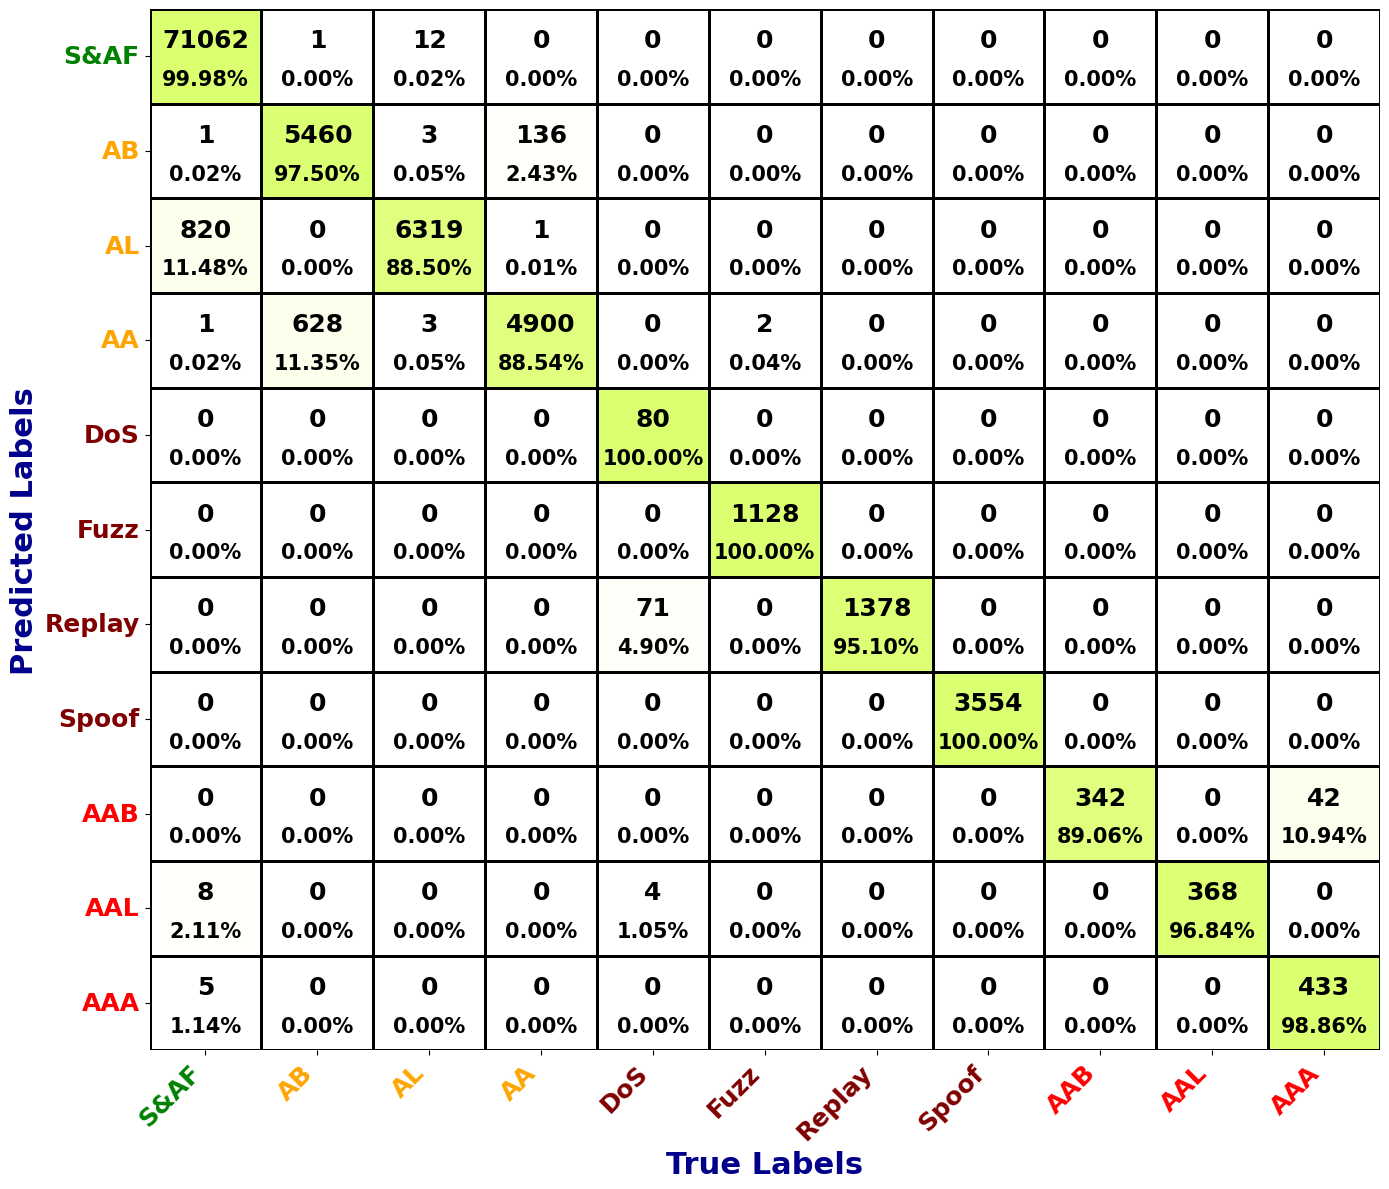

In [5]:
# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "Spoof", "AAB", "AAL", "AAA"]
PlotConfusionMatrixKia(cf_matrix, class_labels)

In [6]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
stats_df

,Class,Support,Precision,Recall,F1,Accuracy,Error_Rate,CI_Lower,CI_Upper,AUC
0,S&AF,71075,0.9884,0.9998,0.9941,0.9998,0.0002,0.9997,0.9999,1.0
1,AB,5600,0.8967,0.9750,0.9342,0.9750,0.0250,0.9706,0.9788,1.0
2,AL,7140,0.9972,0.8850,0.9377,0.8850,0.1150,0.8774,0.8922,1.0
3,AA,5534,0.9728,0.8854,0.9271,0.8854,0.1146,0.8768,0.8936,1.0
4,DoS,80,0.5161,1.0000,0.6809,1.0000,0.0000,0.9542,1.0000,1.0
5,Fuzz,1128,0.9982,1.0000,0.9991,1.0000,0.0000,0.9966,1.0000,1.0
6,Replay,1449,1.0000,0.9510,0.9749,0.9510,0.0490,0.9386,0.9610,1.0
7,Spoof,3554,1.0000,1.0000,1.0000,1.0000,0.0000,0.9989,1.0000,1.0
8,AAB,384,1.0000,0.8906,0.9421,0.8906,0.1094,0.8555,0.9181,1.0
9,AAL,380,1.0000,0.9684,0.9840,0.9684,0.0316,0.9456,0.9818,1.0


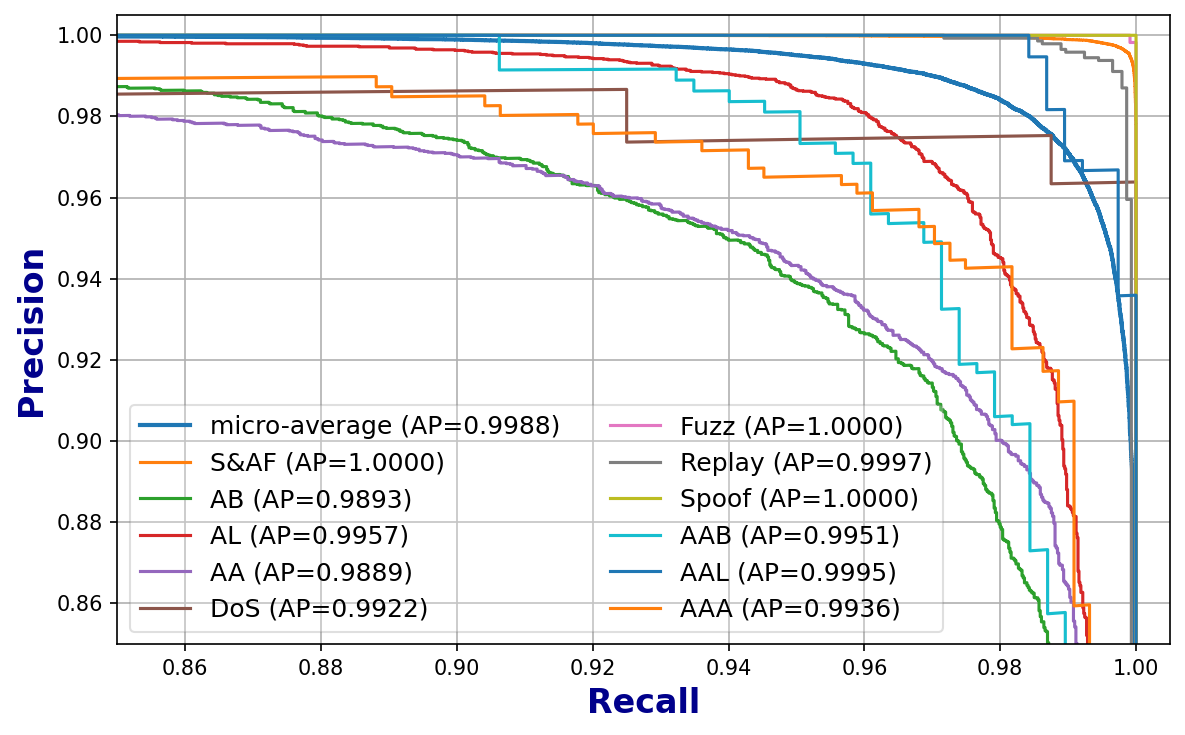

{'AP_micro': 0.9987894031125619,
 'AP_macro': 0.9958096471803132,
 'AP_per_class': {'S&AF': 0.9999590735258961,
  'AB': 0.9892904147349628,
  'AL': 0.9956680958456458,
  'AA': 0.9889156132711084,
  'DoS': 0.9921767905983414,
  'Fuzz': 0.9999984309295173,
  'Replay': 0.999656967204946,
  'Spoof': 1.0,
  'AAB': 0.99509216505391,
  'AAL': 0.9995134713493334,
  'AAA': 0.9936350964697842}}

In [7]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","Spoof", "AAB","AAL","AAA"],
    xlim=(0.85, 1.005),
    ylim=(0.85, 1.005),
)

In [8]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model, trainable_only=True)
print(f"Trainable params: {params:,}")
print(f"Model size (fp32): {params*4/1024/1024:.2f} MB")

Trainable params: 40,267
Model size (fp32): 0.15 MB


In [9]:
from thop import profile

device = next(model.parameters()).device
model.eval()

# Example input for MobileNetV1Lite
x = torch.randn(1, 1, 20, 10).to(device)   # adjust shape if your real input differs

macs, params_thop = profile(model, inputs=(x,), verbose=False)

# THOP returns MACs; FLOPs are often reported as 2 * MACs
flops = 2 * macs

print(f"THOP params: {params_thop:,}")
print(f"MACs : {macs:,}")
print(f"FLOPs: {flops:,}")
print(f"FLOPs (MFLOPs): {flops/1e6:.6f}")

THOP params: 40,267.0
MACs : 809,664.0
FLOPs: 1,619,328.0
FLOPs (MFLOPs): 1.619328
